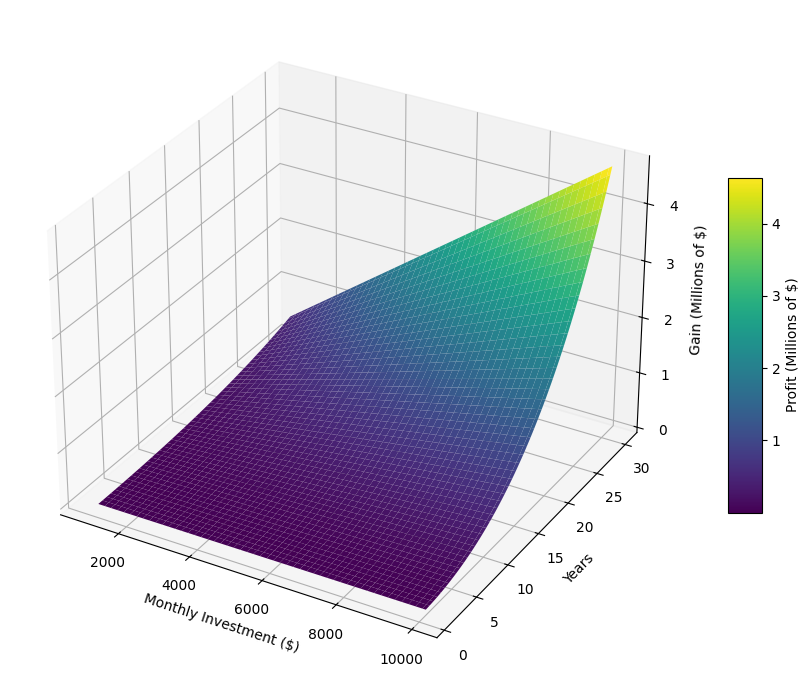

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Parameters
r_annual = 0.05
r_m = r_annual / 12

# Grids
x = np.linspace(1000, 10000, 100)  # monthly investment ($)
y = np.linspace(1, 30, 100)        # years
X, Y = np.meshgrid(x, y)

# Function definition (gain in DOLLARS)
Z = X * (((1 + r_m)**(12 * Y) - 1) / r_m - 12 * Y)

# Convert to millions of dollars
Z_millions = Z / 1e6

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z_millions, cmap='viridis')

# Axis labels
ax.set_xlabel('Monthly Investment ($)')
ax.set_ylabel('Years')
ax.set_zlabel('Gain (Millions of $)')

# Format Z-axis to show digits (like 1, 2, 3...)
ax.zaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))

# Colorbar
cb = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cb.set_label('Profit (Millions of $)')
cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))


plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import ScalarFormatter

# Parameters
r_annual = 0.05
r_monthly = r_annual / 12

# Axes ranges
monthly_investments = np.linspace(0, 10000, 200)
years = np.linspace(0.5, 30, 200)

# Create meshgrid
X, Y = np.meshgrid(monthly_investments, years)
N = Y * 12

# Compound interest formula
Z = X * (((1 + r_monthly)**N - 1) / r_monthly)
Z_millions = Z / 1e6

# Create constant plane at z = 3.5 (in millions)
Z_plane = np.full_like(Z_millions, 3.5)

# Plotting
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(X, Y, Z_millions, cmap='viridis', alpha=0.9)

# Hyperplane at z = 3.5
ax.plot_surface(X, Y, Z_plane, color='red', alpha=0.3, linewidth=0, antialiased=False)

# Labels
ax.set_title(r'$r = 0.05$', fontsize=12)
ax.set_xlabel('Monthly Investment (x)', labelpad=10)
ax.set_ylabel('Years (y)', labelpad=10)
ax.set_zlabel('Total Accumulated (millions $)', labelpad=10)

# Z-axis format
ax.zaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='z')

# Colorbar
cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
cbar.ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.savefig("intersection_3.5.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r_annual = 0.05
r_monthly = r_annual / 12
c = 3.5e6  # Target value

# Axes ranges
x_vals = np.linspace(0, 10000, 1000)
y_vals = np.linspace(0.5, 30, 1000)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute f(x, y)
N = 12 * Y
Z = X * (((1 + r_monthly)**N - 1) / r_monthly)

# Plot the level curve f(x, y) = c
plt.figure(figsize=(8, 6))
CS = plt.contour(X, Y, Z, levels=[c], colors='red')
plt.clabel(CS, inline=True, fontsize=10)
plt.title(r'Solutions to $f(x, y) = 3.5 \times 10^6$')
plt.xlabel('Monthly Investment $x$')
plt.ylabel('Years $y$')
plt.grid(True)
plt.tight_layout()
plt.savefig("intersection_3.5_curve.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
r_m = 0.05
c = 2_000_000  # in dollars

# Grid setup
i_vals = np.linspace(1000, 10000, 100)
y_vals = np.linspace(1, 30, 100)
I, Y = np.meshgrid(i_vals, y_vals)

# Function definition
Z = I * (((1 + r_m)**(12 * Y) - 1) / r_m - 12 * Y)
Z_millions = Z / 1e6  # convert to millions

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(I, Y, Z_millions, cmap='viridis', edgecolor='none', alpha=0.9)

# Hyperplane at z = 2
Z_hyper = np.full_like(Z_millions, 2)
ax.plot_surface(I, Y, Z_hyper, color='red', alpha=0.3)

# Labels
ax.set_xlabel('Monthly Investment ($)')
ax.set_ylabel('Years')
ax.set_zlabel('Total Profit (Millions $)')
ax.set_title('Investment Gain with Hyperplane at $2M')

# Colorbar
cb = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cb.set_label('Total Profit (Millions $)')
cb.formatter.set_powerlimits((0, 0))
cb.ax.yaxis.set_offset_position('left')
cb.update_ticks()

# Z axis formatting: single digit range
zmin, zmax = ax.get_zlim()
ax.set_zticks(np.arange(np.floor(zmin), np.ceil(zmax) + 1, 1))

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

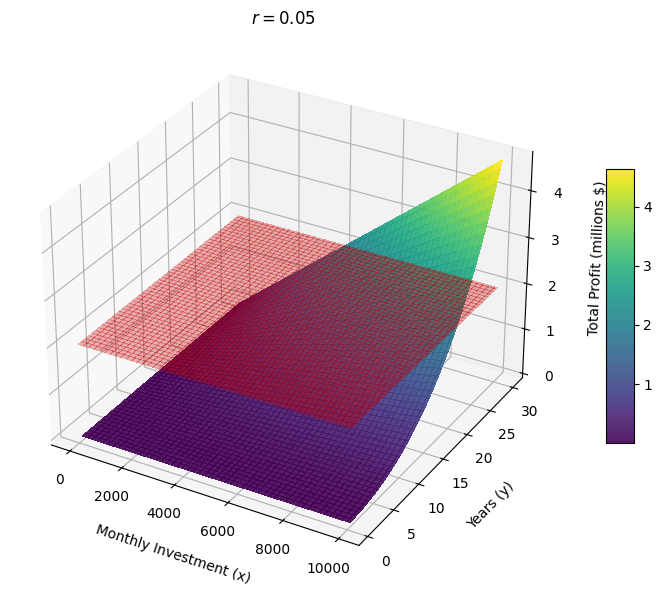

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import ScalarFormatter

# Parameters
r_annual = 0.05
r_monthly = r_annual / 12

# Axes ranges (lower resolution for speed)
monthly_investments = np.linspace(0, 10000, 100)
years = np.linspace(0.5, 30, 100)

# Create meshgrid
X, Y = np.meshgrid(monthly_investments, years)
N = Y * 12

# Corrected compound interest formula
Z = X * (((1 + r_monthly)**N - 1) / r_monthly - 12 * Y)
Z_millions = Z / 1e6

# Hyperplane at z = 2 (in millions)
Z_plane = np.full_like(Z_millions, 2)

# Plotting
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(X, Y, Z_millions, cmap='viridis', alpha=0.9, antialiased=False, linewidth=0)

# Add hyperplane
ax.plot_surface(X, Y, Z_plane, color='red', alpha=0.3, linewidth=0, antialiased=False)

# Labels and formatting
ax.set_title(r'$r = 0.05$', fontsize=12)
ax.set_xlabel('Monthly Investment (x)', labelpad=10)
ax.set_ylabel('Years (y)', labelpad=10)
ax.set_zlabel('Total Profit (millions $)', labelpad=10)

# Z-axis: disable scientific notation
ax.zaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='z')

# Color bar formatting
cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
cbar.ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.savefig("intersection_2.png", dpi=300, bbox_inches='tight')

plt.show()
